In [1]:
import numpy as np

from astropy import units, coordinates
import os
import pandas as pd
from scipy.stats import binned_statistic_2d, binned_statistic_dd
from astropy.table import Table

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('figure_style.mplstyle')


## Read in synthetic populations

In [2]:
# Load in the data
all_csv_files = [
    f.name
    for f in os.scandir("../../science/synthpop/outputfiles/hge_gums_marshall")
    if f.name.endswith(".csv") and f.name.startswith("hge_gums_marshall_")
]

# Concatenate all files
all_stars = [pd.read_csv(f"../../science/synthpop/outputfiles/hge_gums_marshall/{f}") for f in all_csv_files]
all_stars = pd.concat(all_stars)
print(len(all_stars['l']))
print(all_stars.columns)

#Switch inner lons
neg = (all_stars['l'] > 180.)
all_stars.loc[neg, 'l'] = -1.*(360.-all_stars['l'][neg])

# Convert (l,b,dist) to Galactic (R,Z,phi)
all_coords = coordinates.SkyCoord(
    frame="galactic",
    l=all_stars["l"],
    b=all_stars["b"],
    distance=all_stars["Dist"],
    unit=(units.deg, units.deg, units.kpc),
)

all_coords = all_coords.transform_to(coordinates.Galactocentric)
gal_x = all_coords.x / units.kpc
gal_y = all_coords.y / units.kpc
gal_z = all_coords.z / units.kpc
gal_r = np.sqrt(((all_coords.x) ** 2.0) + ((all_coords.y) ** 2.0)) / units.kpc


5612873
Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5'],
      dtype='str')


## Hmag of giants at different R

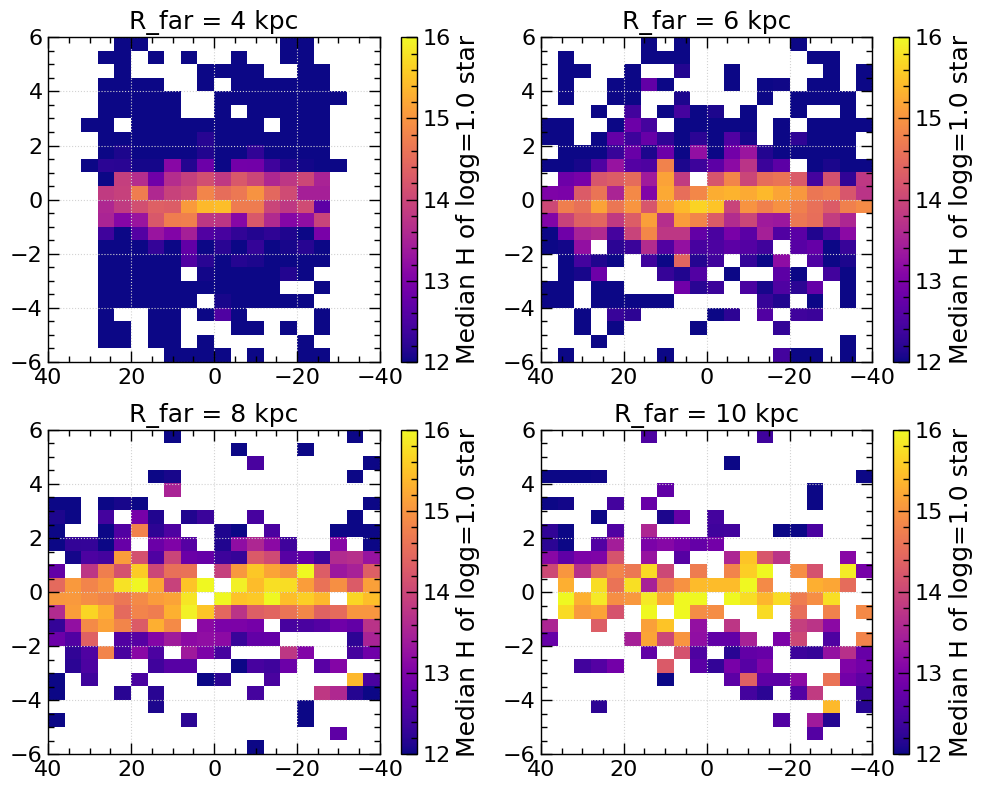

In [4]:
radius_array = [4, 6, 8, 10]
use_logg = 1.0

l_rng = [-40,40]
b_rng = [-6,6]
l_nbins = round(abs(l_rng[0]-l_rng[1])/4.0)
b_nbins = round(abs(b_rng[0]-b_rng[1])/0.5)

fig = plt.figure(figsize=(10,8))

for i_radius, this_radius in enumerate(radius_array):
    gd = np.logical_and.reduce([gal_x > 0,
                                abs(gal_r - this_radius) < 0.5,
                                abs(all_stars['logg'] - use_logg) < 0.25])
    im, xe, ye, bn = binned_statistic_2d(all_stars['l'][gd], all_stars['b'][gd], all_stars['2MASS_H'][gd], statistic='median', 
                                         range=[l_rng,b_rng], bins=[l_nbins,b_nbins])

    ax = plt.subplot(2,2,i_radius+1)
    plt.imshow(np.flip(im.T,axis=0), origin='lower', aspect='auto',
               extent=[max(l_rng),min(l_rng),min(b_rng),max(b_rng)],
               vmin=12.0, vmax=16.0, interpolation='none')
    plt.colorbar(label='Median H of logg={} star'.format(use_logg))
    plt.title(r'R_far = {} kpc'.format(this_radius))

fig.tight_layout()
fig.savefig('fig_l_b_hmag.pdf')
fig.savefig('fig_l_b_hmag.png')

## Max R reachable by H<16 with |Z|<1.0

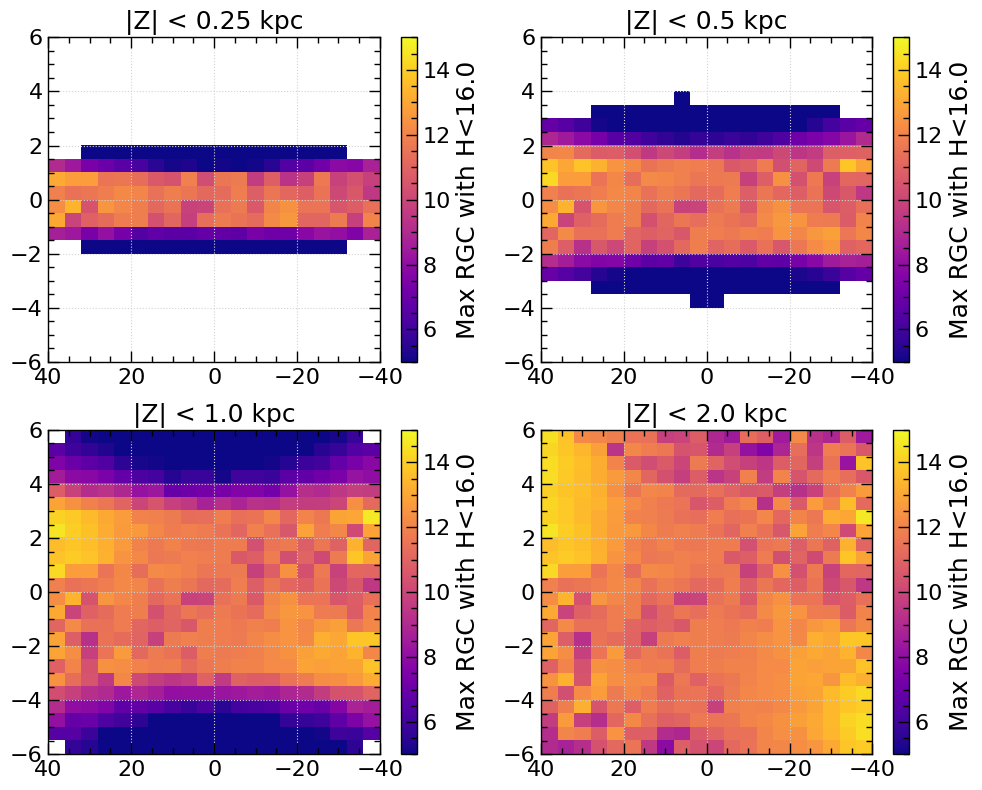

In [5]:
zmax_array = [0.25, 0.5, 1.0, 2.0]
use_hmag_limit = 16.0

fig = plt.figure(figsize=(10,8))

for i_zmax, this_zmax in enumerate(zmax_array):
    gd = np.logical_and.reduce([gal_x > 0,
                                abs(gal_z.value) < this_zmax,
                                all_stars['2MASS_H'] < use_hmag_limit])
    im, xe, ye, bn = binned_statistic_2d(all_stars['l'][gd], all_stars['b'][gd], gal_r[gd], statistic='max', 
                                         range=[l_rng,b_rng], bins=[l_nbins,b_nbins])

    ax = plt.subplot(2,2,i_zmax+1)
    plt.imshow(np.flip(im.T,axis=0), origin='lower', aspect='auto',
               extent=[max(l_rng),min(l_rng),min(b_rng),max(b_rng)],
               vmin=5, vmax=15.0, interpolation='none')
    plt.colorbar(label='Max RGC with H<{}'.format(use_hmag_limit))
    plt.title(r'|Z| < {} kpc'.format(this_zmax))

fig.tight_layout()
fig.savefig('fig_l_b_rmax.pdf')
fig.savefig('fig_l_b_rmax.png')

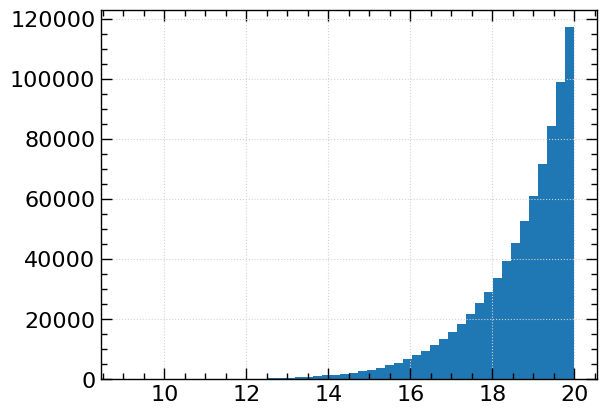

In [8]:
_=plt.hist(all_stars['Gaia_G_EDR3'], range=[9,20], bins=50)

## Hmag, X/Y/Z range with likely GaiaXP parameter estimates

/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_66437/2451115160.py:21: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_xy.T), aspect='auto', origin='lower',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_66437/2451115160.py:31: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_rz.T), aspect='auto', origin='lower',


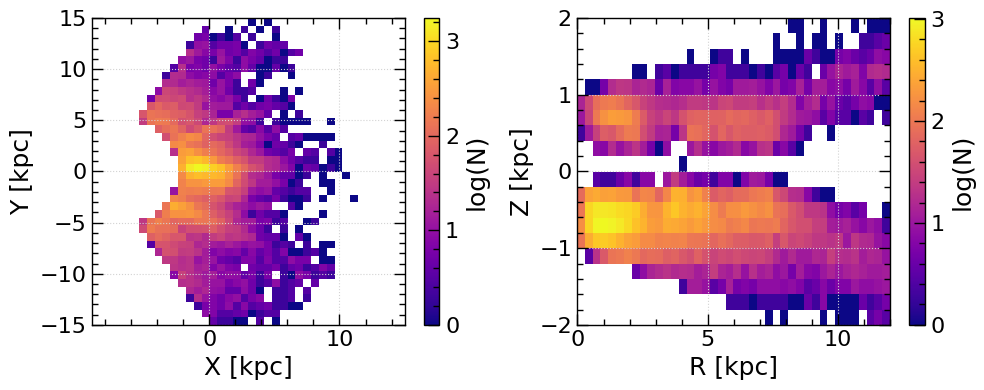

In [12]:
xr = [-9,15]
yr = [-15,15]
zr = [-2,2]
rr = [0,12]
n_xbins = 40
n_ybins = n_xbins
n_zbins = 20
n_rbins = n_xbins

show = np.logical_and.reduce([all_stars['Gaia_G_EDR3'] < 17.65, 
                              all_stars['Dist'] > 6.])

im_xy, xe, ye, bn = binned_statistic_2d(gal_x[show], gal_y[show], all_stars['l'][show], statistic='count',
                                        range=[xr,yr], bins=[n_xbins,n_ybins])
im_rz, xe, ye, bn = binned_statistic_2d(gal_r[show], gal_z[show], all_stars['l'][show], statistic='count',
                                        range=[rr,zr], bins=[n_rbins,n_zbins])

fig = plt.figure(figsize=(10,4))

ax = plt.subplot(121)
plt.imshow(np.log10(im_xy.T), aspect='auto', origin='lower',
           extent=[min(xr),max(xr),min(yr),max(yr)])
plt.colorbar(label='log(N)')
plt.xlim(xr)
plt.ylim(yr)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
#plot_sun_and_gc(ax, size=0.5, add_bar=True)

ax = plt.subplot(122)
plt.imshow(np.log10(im_rz.T), aspect='auto', origin='lower',
           extent=[min(rr),max(rr),min(zr),max(zr)])
plt.colorbar(label='log(N)')
plt.xlim(rr)
plt.ylim(zr)
plt.xlabel('R [kpc]')
plt.ylabel('Z [kpc]')

fig.tight_layout()
fig.savefig('fig_xy_rz_with_gaiaxp.pdf')
fig.savefig('fig_xy_rz_with_gaiaxp.png')